In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import statsmodels.formula.api as smf

In [20]:
df = pd.read_csv("cleaned_data/duolingo_all_languages.csv")

df = df.dropna(subset=["p_recall","delta","learning_language","history_seen","history_correct"])

df["log_delta"] = np.log1p(df["delta"])

### Modeling Approach

We perform two types of modeling to analyze memory retention patterns across languages:
- **Regression modeling using statsmodels** to interpret and test the statistical significance of language-specific differences in forgetting.
- **Random Forest regression using sklearn** to evaluate predictive performance and quantify non-linear feature importance.

The dependent variable is `p_recall`, representing the probability that a learner recalls a word correctly.  
The key predictor is `log(delta)`, representing the time interval after the previous review.  
We include language as a categorical variable, and an interaction term `log_delta * language` to determine whether forgetting rates differ by language.  


### Regression Model

We estimated the following model:

p_recall ~ log(delta) * learning_language + history_seen + history_correct

- `log(delta)` captures the forgetting curve.
- `learning_language` captures baseline differences in recall.
- `log(delta) * learning_language` tests whether the forgetting slope differs by language.
- `history_seen` and `history_correct` control for exposure and learning experience.

The regression output provides coefficient estimates, t-statistics, and p-values to determine whether differences are statistically meaningful.

OLS regression provides interpretable coefficients and hypothesis tests, making it suitable for quantifying how memory decay differs across languages.

In [21]:
# ===========================================
# REGRESSION MODEL with Interaction
# ===========================================

df['learning_language'] = df['learning_language'].astype('category')
df['learning_language'] = df['learning_language'].cat.reorder_categories(
    ['en', 'es', 'fr', 'de', 'it', 'pt'], ordered=False
)

model = smf.ols(
    formula="p_recall ~ log_delta * C(learning_language) + history_seen + history_correct",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               p_recall   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6362.
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:46:07   Log-Likelihood:            -1.4344e+06
No. Observations:            12854226   AIC:                         2.869e+06
Df Residuals:                12854212   BIC:                         2.869e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


**Regression Interpretation (English as Baseline)**

- log_delta is negative and highly significant — recall decreases with longer intervals, confirming the forgetting curve.

- Portuguese, German, Italian, and Spanish show slightly higher baseline recall than English; French shows lower baseline recall.

- Interaction effects indicate different forgetting rates: French and Italian decay more slowly, while German decays faster than English.

- Overall, results suggest language-specific retention differences beyond repetition counts.

### Predicted Forgetting Curves

The figure shows predicted recall probability as review intervals increase.  
Even after controlling for practice history, languages exhibit different forgetting slopes:

- Some languages retain higher recall for longer intervals.
- Others decline more rapidly, indicating faster memory decay.

This provides evidence that language characteristics influence forgetting beyond repetition alone.


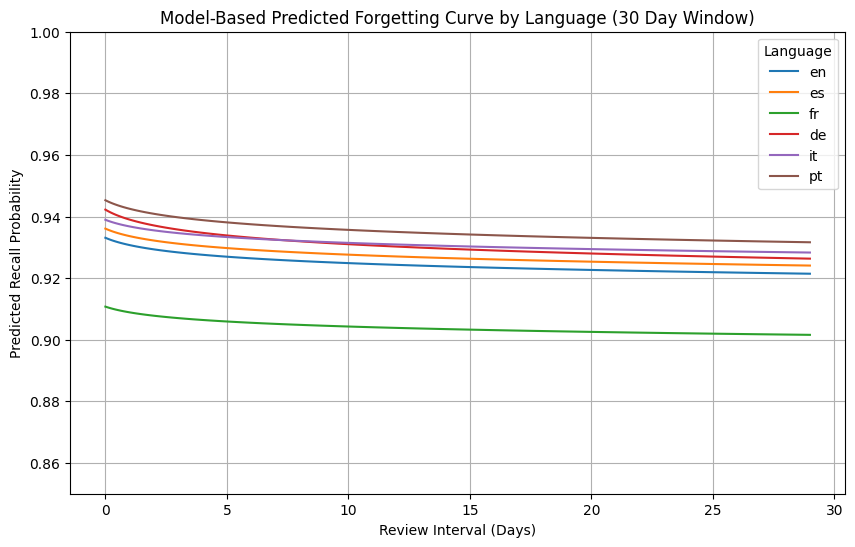

In [22]:
# ===========================================
# PLOT: Predicted forgetting curves per language
# ===========================================

log_delta_range = np.linspace(0, np.log(30), 50)

languages = ["en", "es", "fr", "de", "it", "pt"]

plot_df = pd.DataFrame({
    "log_delta": np.repeat(log_delta_range, len(languages)),
    "learning_language": np.tile(languages, len(log_delta_range)),
    "history_seen": 6,
    "history_correct": 6
})

plot_df["predicted"] = model.predict(plot_df)

plt.figure(figsize=(10, 6))
for lang in languages:
    subset = plot_df[plot_df["learning_language"] == lang]
    plt.plot(np.expm1(subset["log_delta"]), subset["predicted"], label=lang)

plt.title("Model-Based Predicted Forgetting Curve by Language (30 Day Window)")
plt.xlabel("Review Interval (Days)")
plt.ylabel("Predicted Recall Probability")
plt.ylim(0.85, 1.00)
plt.legend(title="Language")
plt.grid(True)
plt.show()

**Model-Based Predicted Forgetting Curves (Controlled for Practice History)**

The model-based curves show that recall probability gradually decreases as the review interval increases, confirming the forgetting curve across all languages. After controlling for prior exposure and correctness history, Portuguese, Italian, and German retain slightly higher predicted recall than English, while French consistently shows the lowest recall level. Although the slopes differ only modestly, these results suggest that retention patterns are not uniform across languages.


### Machine Learning Prediction — Random Forest

A Random Forest regressor was trained to predict recall probability using log(delta), language, and practice history variables.

The feature importance plot indicates which factors contribute the most to prediction. 
log(delta) and history_correct emerge as strong predictors, while language variables still carry influence.


In [23]:
# ===========================================
# RANDOM FOREST MODEL
# ===========================================

ml_df = df[["p_recall", "log_delta", "learning_language", "history_seen", "history_correct"]].copy()

ml_df = pd.get_dummies(ml_df, columns=["learning_language"], drop_first=True)

X = ml_df.drop("p_recall", axis=1)
y = ml_df["p_recall"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest RMSE:", rmse)
print("Random Forest MAE:", mae)
print("R² score:", r2)

Random Forest RMSE: 0.2997053286275093
Random Forest MAE: 0.17134774178980364
R² score: -0.2213846435305935


**Random Forest Predictive Performance**

The Random Forest model shows limited predictive power (RMSE ≈ 0.30, MAE ≈ 0.17, R² < 0), indicating that recall probability cannot be accurately predicted with the available variables alone. This suggests that forgetting behavior is influenced by additional factors not captured in our dataset (e.g., vocabulary difficulty, user focus level, learning context).

However, the model still provides useful insight through feature importance ranking, confirming that review interval and prior performance remain the most influential predictors of recall.

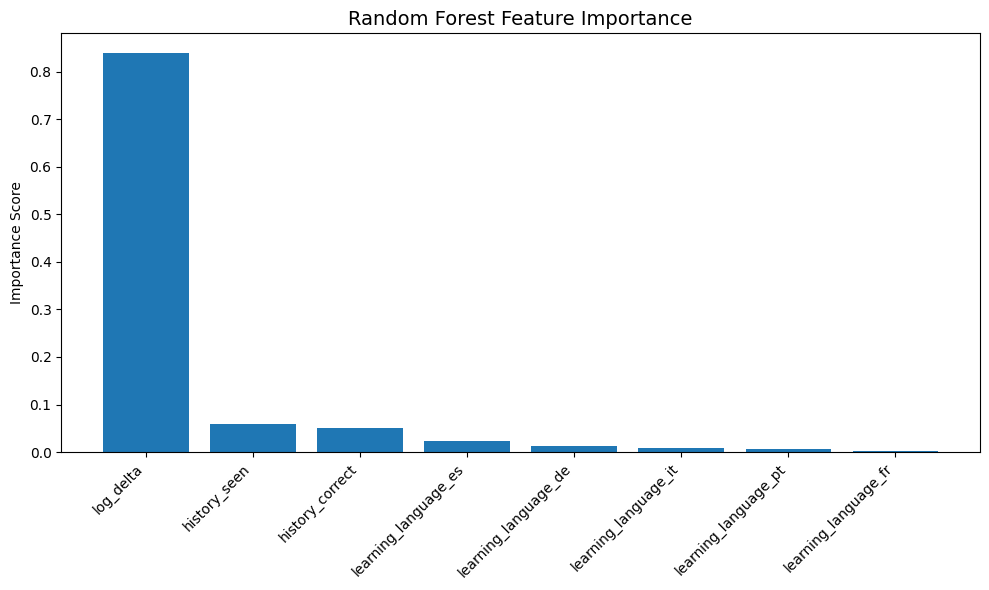

In [25]:
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance", fontsize=14)
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

**Random Forest Feature Importance**

The Random Forest regression provides a non-linear perspective on which variables contribute most to recall prediction.

**Key observations:**
- **`log_delta` overwhelmingly dominates** feature importance (~85%), confirming that **time since previous review is the primary driver of forgetting**.
- **`history_seen` and `history_correct` contribute modest predictive power**, indicating that practice frequency and prior success help retention but are secondary.
- **Language features contribute very little** to predictive performance, aligning with our regression findings that language differences exist but have **small practical effect sizes**.


### Modeling Summary

- **OLS regression** confirms that a forgetting curve exists — the coefficient for log_delta is significantly negative, indicating that recall consistently decreases as the review interval increases.

- The interaction terms demonstrate **statistically significant but modest differences across languages**, suggesting that the forgetting slope varies, yet the overall pattern is largely shared.

- The **predicted forgetting curves** derived from OLS visually validate these findings, showing parallel declining trajectories with small cross-language differences.

- **Random Forest regression**, used to test predictive capability, produced a **negative R²**, indicating that the current features are insufficient to accurately predict recall probability and suggesting the presence of additional unobserved factors (e.g., learner identity, item difficulty, content type).

- However, its **feature importance analysis** aligns with our regression results — log_delta remains the overwhelmingly dominant predictor, while language contributes relatively little to model performance.

- Together, these results suggest that **time since review is the key factor driving memory decay**, whereas language differences exist **but have limited practical predictive value**.